In [ ]:
from preprocess_data import load_and_preprocess_data
from siren import *

import torch 
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
import pandas as pd
import os
import folium
from folium.plugins import HeatMap
import branca.colormap as cm
from sklearn.preprocessing import MinMaxScaler

torch.manual_seed(42) # For replicability

DRAFTING = not torch.cuda.is_available() # if we only have CPU only check if it runs at all. Do proper training on HPC GPU

In [ ]:
coords, prices, coord_scaler, price_scaler = load_and_preprocess_data()

_T = lambda a: torch.tensor(a, dtype=torch.float32)
dataset = TensorDataset(_T(coords), _T(prices))

train_dl, val_dl, test_dl = [DataLoader(ds, batch_size=128) for ds in 
                             random_split(dataset, [0.7, 0.15, 0.15])]

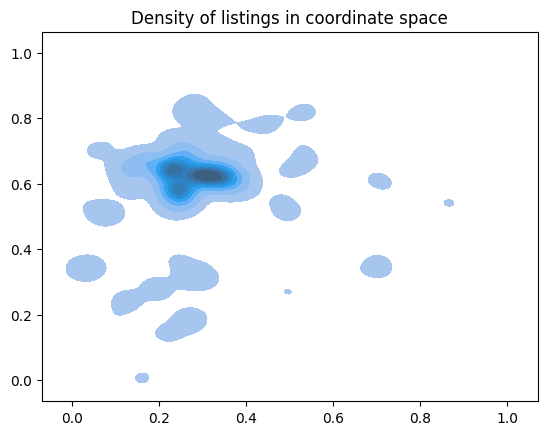

In [ ]:
sns.kdeplot(x=coords[:,0], y=coords[:,1], fill=True)
plt.title("Density of listings in coordinate space")
plt.show()

In [ ]:
model = Siren([2, 128, 64, 32, 1])

Epoch 1, Loss: 0.0220
Epoch 2, Loss: 0.0035
Epoch 3, Loss: 0.0025
Epoch 4, Loss: 0.0020
Epoch 5, Loss: 0.0019
Epoch 6, Loss: 0.0016
Epoch 7, Loss: 0.0014
Epoch 8, Loss: 0.0012
Epoch 9, Loss: 0.0010
Epoch 10, Loss: 0.0009
It took 1.0630 seconds to train


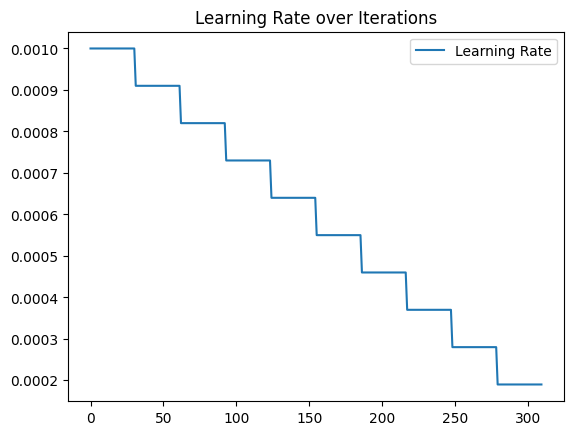

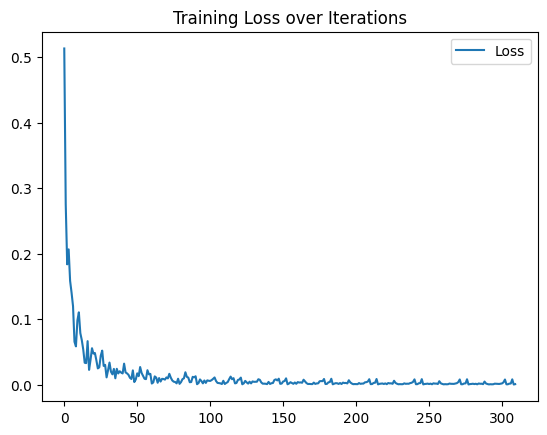

In [ ]:
epochs = 10 if DRAFTING else 300

lossf = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(), # Model parameters to update
    lr=1e-3, # Peak learning rate
)

lr_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, 
    start_factor=1, 
    end_factor=0.1,
    total_iters=epochs,
)

start_time = time.perf_counter()
lrs, losses = [], []
for e in range(epochs):
    for X,Y in train_dl:
        optimizer.zero_grad()
        Z = model(X)
        loss = lossf(Z, Y)
        loss.backward()
        optimizer.step()
        lrs.append(optimizer.param_groups[0]['lr'])
        losses.append(loss.item())
    if lr_scheduler is not None:
        lr_scheduler.step()
    
    print(f"Epoch {e+1}, Loss: {loss.item():.4f}")

end_time = time.perf_counter()
print(f"It took {end_time - start_time:0.4f} seconds to train")

# Plot Learning Rate and Loss
sns.lineplot(x=range(len(lrs)), y=lrs, label='Learning Rate')
plt.title("Learning Rate over Iterations")
plt.show()

sns.lineplot(x=range(len(losses)), y=losses, label='Loss')
plt.title("Training Loss over Iterations")
plt.show()

In [ ]:
def generate_prediction_heatmap(
    df,
    price_column='predicted_price',
    output_path='hongkong_price_heatmap.html',
    coord_scaler=None,
    price_scaler=None,
    coords_scaled=None
):
    """
    Generate a heatmap from model predictions on a real-world coordinate map.

    Args:
        df (pd.DataFrame): DataFrame with normalized 'latitude', 'longitude', and price_column.
        price_column (str): Column name with price or predicted price (already normalized).
        output_path (str): Where to save the HTML file.
        coord_scaler (MinMaxScaler): scaler used to normalize lat/lon coords (for inverse transform).
        price_scaler (MinMaxScaler): scaler used to normalize prices (for inverse transform).
    """
    required_columns = {'latitude', 'longitude', price_column}
    if not required_columns.issubset(df.columns):
        raise ValueError(f"DataFrame must contain columns: {required_columns}")
    if coord_scaler is None or price_scaler is None:
        raise ValueError("coord_scaler and price_scaler must be provided for denormalization.")

    df = df.dropna(subset=['latitude', 'longitude', price_column])

    # Denormalize lat/lon to real coordinates
    coords_denorm = coord_scaler.inverse_transform(df[['latitude', 'longitude']])
    df['latitude_denorm'] = coords_denorm[:, 0]
    df['longitude_denorm'] = coords_denorm[:, 1]

    # Use normalized prices for heatmap intensity
    heat_data = df[['latitude_denorm', 'longitude_denorm', price_column]].values.tolist()

    # Create map centered roughly at mean coordinate (denormalized)
    center_lat = df['latitude_denorm'].mean()
    center_lon = df['longitude_denorm'].mean()
    m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

    # Add heatmap layer
    HeatMap(heat_data, radius=15, max_zoom=13).add_to(m)

    # Denormalize prices for the legend
    denorm_price_min = price_scaler.inverse_transform([[df[price_column].min()]])[0][0]
    denorm_price_max = price_scaler.inverse_transform([[df[price_column].max()]])[0][0]

    colormap = cm.LinearColormap(
        colors=['blue', 'lime', 'red'],
        vmin=denorm_price_min,
        vmax=denorm_price_max,
        caption='Predicted Price (denormalized)'
    )
    colormap.add_to(m)

    # === Add original training data points as dots ===
    original_coords = coord_scaler.inverse_transform(coords_scaled)  # coords_scaled from your data loading
    for lat, lon in original_coords:
      folium.CircleMarker(
        location=[lat, lon],
        radius=2,
        color='black',
        fill=True,
        fill_opacity=0.6,
        weight=0
      ).add_to(m)

    # Ensure output directory exists
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    # Save HTML map
    m.save(output_path)
    print(f"✅ Heatmap saved as '{output_path}'")
    print(f"Price range shown in legend: {denorm_price_min:.2f} to {denorm_price_max:.2f}")

In [ ]:
# Load and preprocess your data
coords_scaled, prices_scaled, coord_scaler, price_scaler = load_and_preprocess_data()


# Assuming you have a trained model and _T is your tensor transform function:
import torch

with torch.no_grad():
    coords_tensor = _T(coords_scaled)  # Your tensor conversion here
    preds = model(coords_tensor).squeeze().numpy()  # Model predictions, expected normalized in [0,1]

# Prepare DataFrame for heatmap generation
predictions_df = pd.DataFrame({
    'latitude': coords_scaled[:, 0],    # normalized latitudes
    'longitude': coords_scaled[:, 1],   # normalized longitudes
    'predicted_price': preds             # normalized predicted prices
})

# Generate the heatmap with denormalization for coordinates and price legend
generate_prediction_heatmap(
    predictions_df,
    price_column='predicted_price',
    output_path='outputs/hongkong_price_heatmap.html',
    coord_scaler=coord_scaler,
    price_scaler=price_scaler,
    coords_scaled=coords_scaled
)

✅ Heatmap saved as 'outputs/hongkong_price_heatmap.html'
Price range shown in legend: -952.72 to 1488.49
